model : /kaggle/input/models/bhanukachamindu/aloe-colour/other/default/1/colour_model.keras
labels: /kaggle/input/models/bhanukachamindu/aloe-colour/other/default/1/colour_labels.txt


2026-09-21 06:37:56.325435: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model classes: ['brown', 'green', 'yellow']
Unseen folder: /kaggle/input/datasets/bhanukachamindu/unseen-colour/Unseen_Test_Images_Colour
✗  brown_0001.jpeg                actual: brown              predicted: yellow             (98.54%)
✗  brown_0002.jpg                 actual: brown              predicted: yellow             (100.0%)
✗  brown_0003.jpg                 actual: brown              predicted: yellow             (98.85%)
✗  brown_0004.png                 actual: brown              predicted: yellow             (100.0%)
✗  brown_0005.png                 actual: brown              predicted: yellow             (97.61%)
✗  brown_0006.png                 actual: brown              predicted: yellow             (99.97%)
✗  brown_0007.png                 actual: brown              predicted: yellow             (98.93%)
✗  brown_0008.jpg                 actual: brown              predicted: yellow             (100.0%)
✗  green_0001.jpeg                actual: green              p

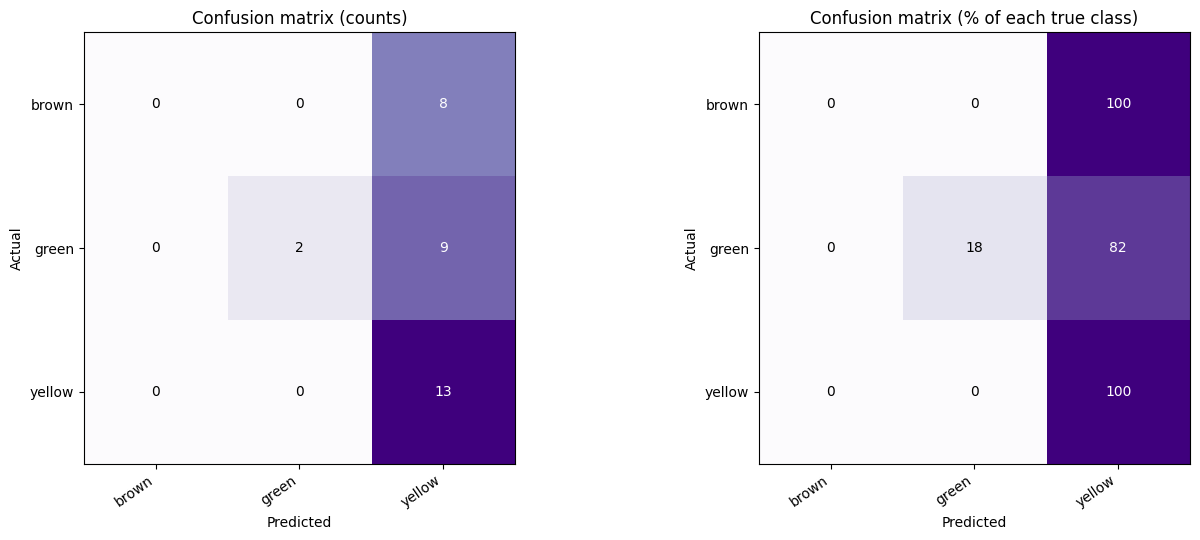

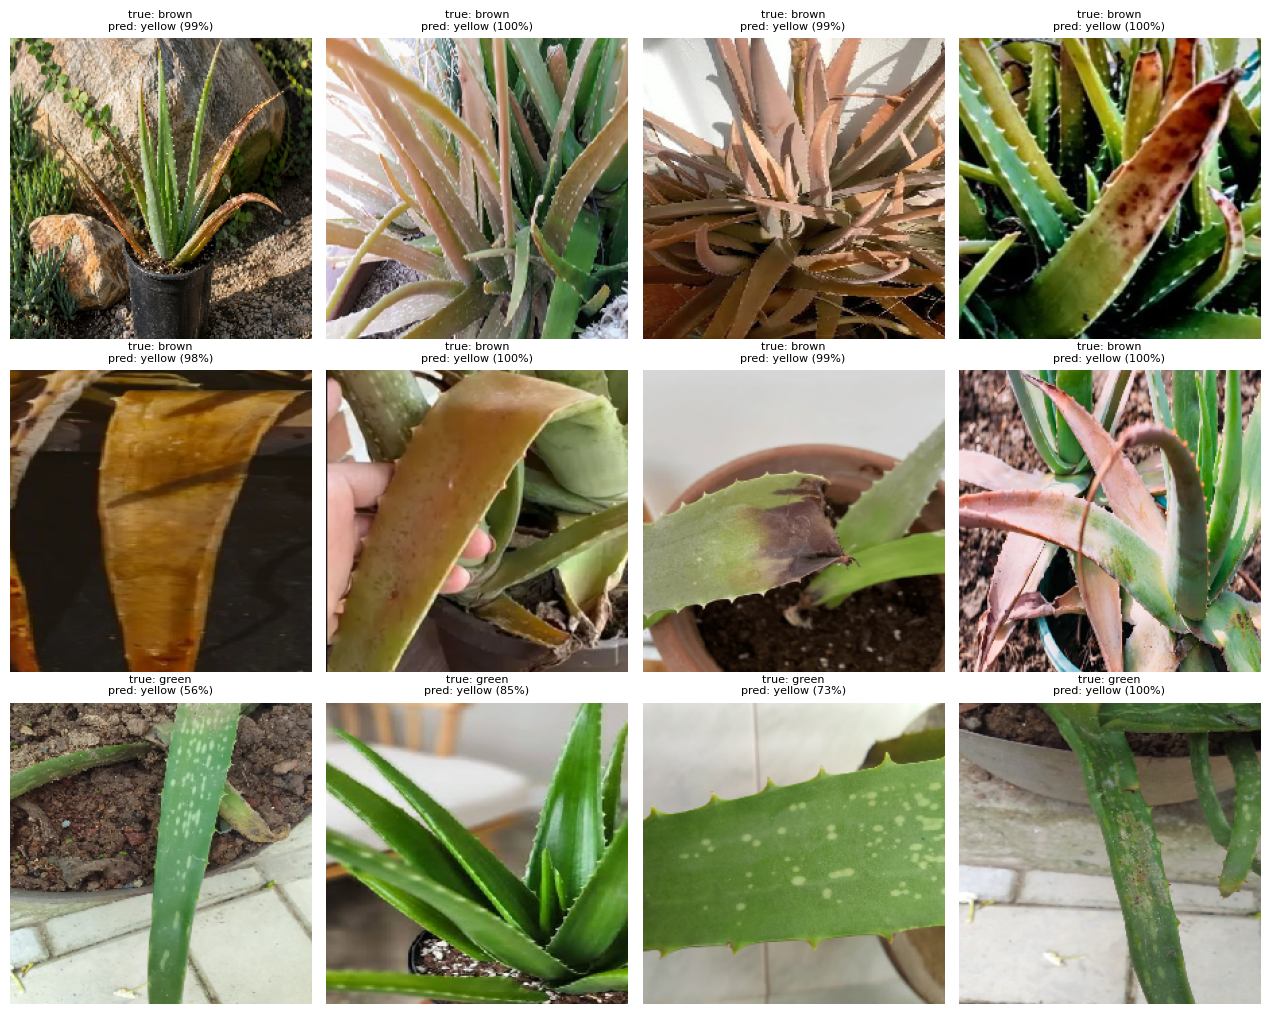

In [4]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ---------------- SETTINGS ----------------
UNSEEN_DIR = "/kaggle/input/datasets/bhanukachamindu/unseen-colour"     
MODEL_PATH = None      # None = find colour_model.keras automatically
LABELS_PATH = None     # None = find colour_labels.txt automatically
IMG_SIZE = (224, 224)
# ------------------------------------------

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def find_file(name):
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        hits = sorted(base.rglob(name))
        if hits:
            return hits[0]
    return None

def show_tree(folder, depth=0, max_depth=3):
    folder = Path(folder)
    n = sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMG_EXT)
    print("    " * depth + f"{folder.name}/  ({n} images)")
    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

if UNSEEN_DIR is None:
    print("UNSEEN_DIR is not set yet. These are the folders in your notebook's Input:\n")
    show_tree("/kaggle/input", max_depth=6)
    raise ValueError("Copy the path of your unseen-photos folder into UNSEEN_DIR above and run again.")

MODEL_PATH = Path(MODEL_PATH) if MODEL_PATH else find_file("colour_model.keras")
LABELS_PATH = Path(LABELS_PATH) if LABELS_PATH else find_file("colour_labels.txt")
if MODEL_PATH is None or LABELS_PATH is None:
    raise FileNotFoundError("Could not find colour_model.keras / colour_labels.txt. Set MODEL_PATH and LABELS_PATH above.")
print("model :", MODEL_PATH)
print("labels:", LABELS_PATH)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
CLASS_NAMES = [l.strip() for l in open(LABELS_PATH) if l.strip()]
print("Model classes:", CLASS_NAMES)

def to_class(folder_name):
    key = re.sub(r"[\s\-]+", "_", folder_name.strip().lower())
    return key

# go down through wrapper folders until we reach the class folders
root = Path(UNSEEN_DIR)
while True:
    subs = [d for d in root.iterdir() if d.is_dir()]
    has_img = any(f.suffix.lower() in IMG_EXT for f in root.iterdir() if f.is_file())
    if len(subs) == 1 and not has_img:
        root = subs[0]
    else:
        break
print("Unseen folder:", root)
if "aloe_vera_dataset_colour" in str(root).lower():
    print("!! This looks like your TRAINING dataset. Testing on it tells you nothing. Use new photos.")

true_labels, pred_labels, results = [], [], []

for folder in sorted(p for p in root.iterdir() if p.is_dir()):
    class_name = to_class(folder.name)
    if class_name not in CLASS_NAMES:
        print(f"SKIPPED folder '{folder.name}': the model has no class called '{class_name}'")
        continue
    true_idx = CLASS_NAMES.index(class_name)

    for f in sorted(folder.rglob("*")):
        if f.suffix.lower() not in IMG_EXT:
            continue
        img = tf.keras.utils.load_img(f, target_size=IMG_SIZE)
        arr = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)   # keep 0-255, the model rescales inside
        probs = model.predict(arr, verbose=0)[0]
        pred_idx = int(np.argmax(probs))

        true_labels.append(true_idx)
        pred_labels.append(pred_idx)
        results.append({"file": f.name, "path": str(f), "actual": class_name,
                        "predicted": CLASS_NAMES[pred_idx], "confidence": round(float(probs[pred_idx]) * 100, 2)})

if not results:
    raise ValueError("No images found in class folders. Arrange them like: <unseen>/Green/, <unseen>/Yellow/, "
                     "<unseen>/Brown/ (upper/lower case does not matter).")

res = pd.DataFrame(results)
res.drop(columns="path").to_csv("/kaggle/working/unseen_colour_results.csv", index=False)

# ---- per-image results ----
for r in results:
    mark = "✓" if r["actual"] == r["predicted"] else "✗"
    print(f"{mark}  {r['file']:30s} actual: {r['actual']:18s} predicted: {r['predicted']:18s} ({r['confidence']}%)")

# ---- overall ----
labels = list(range(len(CLASS_NAMES)))
accuracy = np.mean(np.array(true_labels) == np.array(pred_labels)) * 100
print(f"\nUnseen test images: {len(results)}")
print(f"Unseen test accuracy: {accuracy:.2f}%")
print(f"Macro F1: {f1_score(true_labels, pred_labels, labels=labels, average='macro', zero_division=0):.3f}\n")
print(classification_report(true_labels, pred_labels, labels=labels,
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

# ---- good vs not good (green = good, yellow and brown = not good) ----
GOOD_CLASSES = {"green"}
good_true = np.array([CLASS_NAMES[i].lower() in GOOD_CLASSES for i in true_labels])
good_pred = np.array([CLASS_NAMES[i].lower() in GOOD_CLASSES for i in pred_labels])
print("Good vs not-good accuracy:", round((good_true == good_pred).mean() * 100, 2), "%")
print(classification_report(good_true, good_pred, target_names=["not good (yellow/brown)", "good (green)"],
                            digits=3, zero_division=0))
print(f"Not-good leaves predicted as GOOD: {int(((~good_true) & good_pred).sum())}   <- the costlier mistake")
print(f"Good leaves predicted as not good: {int((good_true & (~good_pred)).sum())}\n")

# ---- confusion matrix ----
cm = confusion_matrix(true_labels, pred_labels, labels=labels)
cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1) * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, data, title, fmt in [(ax[0], cm, "Confusion matrix (counts)", "d"),
                            (ax[1], cm_pct, "Confusion matrix (% of each true class)", ".0f")]:
    a.imshow(data, cmap="Purples")
    a.set_xticks(labels); a.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
    a.set_yticks(labels); a.set_yticklabels(CLASS_NAMES)
    a.set_xlabel("Predicted"); a.set_ylabel("Actual"); a.set_title(title)
    for i in labels:
        for j in labels:
            a.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                   color="white" if data[i, j] > data.max() / 2 else "black")
plt.tight_layout(); plt.show()

# ---- the mistakes ----
wrong = res[res.actual != res.predicted].head(12)
if len(wrong):
    cols = 4
    rows = int(np.ceil(len(wrong) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, (_, r) in zip(axes.ravel(), wrong.iterrows()):
        a.imshow(tf.keras.utils.load_img(r["path"], target_size=IMG_SIZE))
        a.set_title(f"true: {r['actual']}\npred: {r['predicted']} ({r['confidence']:.0f}%)", fontsize=8)
    plt.tight_layout(); plt.show()